# RNN — PyTorch Pipeline

## Model: Recurrent Neural Network (Vanilla RNN + GRU)
- **Dataset**: ECG5000 — 4,000 train / 1,000 test, 140 timesteps, 5 heartbeat classes
- **Task**: Classify heartbeat arrhythmias (severe class imbalance: 121.6x ratio)
- **Framework showcase**: Vanishing gradient demonstration + GRU as the fix + architecture sweep

## Evaluation Strategy
- **Primary metric**: Macro F1 (not accuracy — 58% majority class makes accuracy misleading)
- **Training curves**: Loss + accuracy + macro F1 (train/val)
- **Gradient analysis**: Per-layer gradient norms comparing vanilla RNN vs GRU

## Pipeline
1. Load data + config
2. Vanilla RNN baseline
3. Vanishing gradient demonstration
4. GRU model (gated fix)
5. Architecture sweep (hidden size, depth, bidirectional)
6. Best model — full evaluation
7. Training visualization
8. Performance benchmarks
9. Save results

In [1]:
# Step 1: Setup
"""
Imports, config, load preprocessed ECG5000, class weights to GPU
Input shape: (batch, 140, 1) — sequence of 140 timesteps, 1 feature
Class weights from preprocessing metadata (121.6x imbalance)
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import sys
import os
sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.metrics import evaluate_classifier, macro_f1_score
from utils.rnn_utils import compute_gradient_norms
from utils.visualization import (plot_training_history, plot_confusion_matrix_multiclass,
                                  plot_gradient_flow, plot_ecg_predictions,
                                  plot_hidden_state_evolution)
from utils.performance import track_performance, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

# Config
RANDOM_STATE = 113
FRAMEWORK = "PyTorch"
MODEL_NAME = "RNN"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

BATCH_SIZE = 64
N_CLASSES = 5
SEQ_LEN = 140
N_FEATURES = 1
CLASS_NAMES = ['Normal', 'R-on-T PVC', 'PVC', 'SP', 'UB']

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(RANDOM_STATE)

# Load data
X_train, X_test, y_train, y_test, metadata = load_processed_data('rnn')

# Class weights from preprocessing (inverse frequency for 121.6x imbalance)
class_weights = metadata['class_weights']
class_weights_tensor = torch.tensor(
    [class_weights[str(i)] for i in range(N_CLASSES)],
    dtype=torch.float32
).to(device)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

# DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

print("=" * 60)
print(f"[1/9] {FRAMEWORK} — {MODEL_NAME} Pipeline")
print("=" * 60)
print(f"Device: {device} ({torch.cuda.get_device_name() if torch.cuda.is_available() else 'CPU'})")
print(f"Train: {X_train_t.shape} | Test: {X_test_t.shape}")
print(f"Sequence: {SEQ_LEN} timesteps x {N_FEATURES} feature")
print(f"Classes: {N_CLASSES} ({', '.join(CLASS_NAMES)})")
print(f"Batch size: {BATCH_SIZE} ({len(train_loader)} batches/epoch)")
print(f"Class imbalance: {max(class_weights.values()) / min(class_weights.values()):.1f}x")
print(f"Class weights: {[f'{class_weights[str(i)]:.2f}' for i in range(N_CLASSES)]}")

[1/9] PyTorch — RNN Pipeline
Device: cuda (NVIDIA GeForce RTX 4090)
Train: torch.Size([4000, 140, 1]) | Test: torch.Size([1000, 140, 1])
Sequence: 140 timesteps x 1 feature
Classes: 5 (Normal, R-on-T PVC, PVC, SP, UB)
Batch size: 64 (63 batches/epoch)
Class imbalance: 122.9x
Class weights: ['0.34', '0.57', '10.39', '5.16', '42.11']


In [ ]:
# Step 2: Vanilla RNN Baseline
"""
nn.RNN with tanh activation — the simplest recurrent architecture
Uses last hidden state (timestep 140) for classification
Expect: decent accuracy but poor macro F1 on minority classes
Vanilla RNN suffers from vanishing gradients — proven in Cell 3
"""

print("=" * 60)
print("[2/9] Vanilla RNN — Baseline")
print("=" * 60)


class VanillaRNN(nn.Module):
    """
    Simple RNN for sequence classification.

    Args:
        input_size: Features per timestep (1 for univariate ECG)
        hidden_size: RNN hidden dimension
        num_layers: Stacked RNN layers
        n_classes: Output classes
    """
    def __init__(self, input_size, hidden_size, num_layers, n_classes):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers,
                           batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, n_classes)

    def forward(self, x):
        # x: (batch, seq_len, features)
        output, h_n = self.rnn(x)
        # Use last timestep output for classification
        last_hidden = output[:, -1, :]
        return self.fc(last_hidden)


def train_rnn(model, train_loader, criterion, max_epochs=50, patience=10, lr=1e-3):
    # Train RNN with early stopping on validation macro F1
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train/val split from loaded tensors
    n_val = int(len(X_train_t) * 0.1)
    perm = torch.randperm(len(X_train_t), device=device,
                           generator=torch.Generator(device=device).manual_seed(RANDOM_STATE))
    val_idx, tr_idx = perm[:n_val], perm[n_val:]

    X_val = X_train_t[val_idx]
    y_val = y_train_t[val_idx]

    tr_ds = TensorDataset(X_train_t[tr_idx], y_train_t[tr_idx])
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

    best_val_f1 = 0.0
    wait = 0
    best_state = None
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0

        for batch_x, batch_y in tr_loader:
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch_y)
            correct += (logits.argmax(1) == batch_y).sum().item()
            total += len(batch_y)

        train_losses.append(epoch_loss / total)
        train_accs.append(correct / total)

        # Validate
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val).item()
            val_preds = val_logits.argmax(1).cpu().numpy()
            val_acc = float((val_preds == y_val.cpu().numpy()).mean())
            val_f1 = float(macro_f1_score(y_val.cpu().numpy(), val_preds))

        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            wait = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)

    return {
        'train_loss': train_losses, 'val_loss': val_losses,
        'train_acc': train_accs, 'val_acc': val_accs,
        'epochs': len(train_losses), 'best_val_f1': best_val_f1
    }


# Build and train vanilla RNN
vanilla_rnn = VanillaRNN(N_FEATURES, hidden_size=64, num_layers=2,
                          n_classes=N_CLASSES).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

n_params_vanilla = sum(p.numel() for p in vanilla_rnn.parameters())
print(f"Architecture: RNN(1, 64, 2 layers) -> FC(64, 5)")
print(f"Parameters: {n_params_vanilla:,}")

with track_performance(gpu=True) as perf_vanilla:
    hist_vanilla = train_rnn(vanilla_rnn, train_loader, criterion,
                              max_epochs=50, patience=10)
    torch.cuda.synchronize()

# Evaluate on test
vanilla_rnn.eval()
with torch.no_grad():
    test_logits = vanilla_rnn(X_test_t)
    vanilla_preds = test_logits.argmax(1).cpu().numpy()

vanilla_metrics = evaluate_classifier(y_test, vanilla_preds)
vanilla_f1, vanilla_per_class = macro_f1_score(y_test, vanilla_preds, return_per_class=True)

print(f"\nEpochs: {hist_vanilla['epochs']} | Best val F1: {hist_vanilla['best_val_f1']:.4f}")
print(f"Training time: {perf_vanilla['time']:.2f}s")
print(f"\nTest Results:")
print(f"  Accuracy:  {vanilla_metrics['accuracy']:.4f}")
print(f"  Macro F1:  {vanilla_f1:.4f}")
print(f"\nPer-class F1:")
for i, (name, f1) in enumerate(zip(CLASS_NAMES, vanilla_per_class)):
    print(f"  {name:<15} F1={f1:.4f} (n={np.sum(y_test == i)})")


[2/9] Vanilla RNN — Baseline
Architecture: RNN(1, 64, 2 layers) -> FC(64, 5)
Parameters: 12,933

Epochs: 28 | Best val F1: 0.5368
Training time: 7.11s

Test Results:
  Accuracy:  0.8460
  Macro F1:  0.4938

Per-class F1:
  Normal          F1=0.9539 (n=584)
  R-on-T PVC      F1=0.8637 (n=353)
  PVC             F1=0.2917 (n=19)
  SP              F1=0.3235 (n=39)
  UB              F1=0.0364 (n=5)


[3/9] Vanishing Gradient Demonstration
Vanilla RNN — Gradient Norms (L2):
---------------------------------------------
  rnn.weight_ih_l0                    4.370973e-01
  rnn.weight_hh_l0                    1.577275e+00
  rnn.bias_ih_l0                      3.204504e-01
  rnn.bias_hh_l0                      3.204504e-01
  rnn.weight_ih_l1                    4.497405e-01
  rnn.weight_hh_l1                    9.578745e-01
  rnn.bias_ih_l1                      1.133305e-01
  rnn.bias_hh_l1                      1.133305e-01
  fc.weight                           1.845902e+00
  fc.bias                             2.615404e-01

Gradient range: 4.37e-01 → 1.85e+00
Max/min ratio: 4.2x


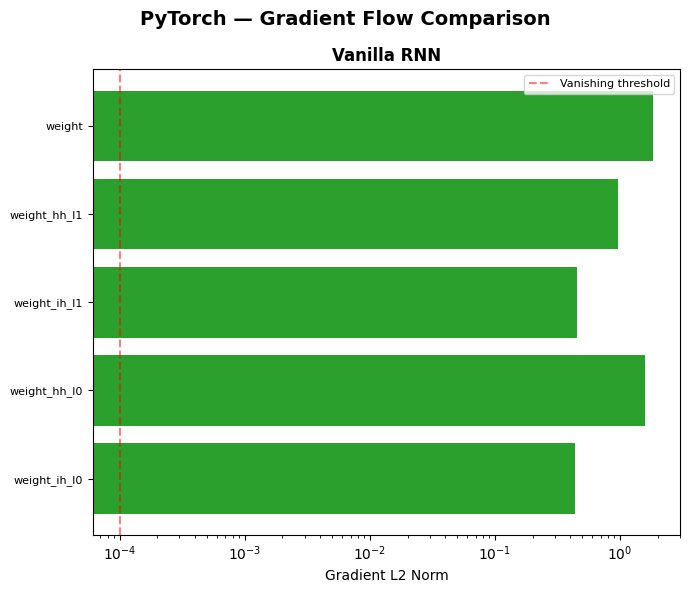

In [5]:
# Step 3: Vanishing Gradient Demonstration
"""
THE key pedagogical cell — proves WHY gated architectures exist.
compute_gradient_norms() does a forward+backward pass on a small batch,
then measures L2 norm of gradients at each layer.

Vanilla RNN: gradients shrink exponentially through layers (vanishing)
GRU (trained next cell): reset/update gates preserve gradient flow
"""

print("=" * 60)
print("[3/9] Vanishing Gradient Demonstration")
print("=" * 60)

# Use a small batch for gradient computation
grad_batch_x = X_train_t[:64]
grad_batch_y = y_train_t[:64]

# Compute gradient norms for vanilla RNN
vanilla_grads = compute_gradient_norms(
    vanilla_rnn, criterion, grad_batch_x, grad_batch_y, framework='pytorch'
)

print("Vanilla RNN — Gradient Norms (L2):")
print("-" * 45)
for name, norm in vanilla_grads.items():
    tag = " ← VANISHING" if norm < 1e-4 else ""
    print(f"  {name:<35} {norm:.6e}{tag}")

# Summary stats
weight_grads = {k: v for k, v in vanilla_grads.items() if 'weight' in k}
min_grad = min(weight_grads.values())
max_grad = max(weight_grads.values())
ratio = max_grad / min_grad if min_grad > 0 else float('inf')

print(f"\nGradient range: {min_grad:.2e} → {max_grad:.2e}")
print(f"Max/min ratio: {ratio:.1f}x")
if ratio > 100:
    print("  Large gradient ratio confirms vanishing gradient problem")
    print("  Early layers receive ~0 gradient → can't learn long-range patterns")
    print("  This is why GRU/LSTM gates were invented")

# Plot — just vanilla RNN for now (GRU added after Cell 4)
plot_gradient_flow({'Vanilla RNN': vanilla_grads}, framework='PyTorch',
                   save_path='results/gradient_flow_vanilla.png')